In [47]:
import numpy as np
import PyWSINDy_ODE.wsindy as ws
import PyWSINDy_ODE.ODE_examples as ODE_examples 
import matplotlib.pylab as plt
from scipy.integrate import solve_ivp
from mpl_toolkits import mplot3d

from agl_helpers import addNoise, recoverDynamics

def addNoise(x, noise_ratio):
    signal_power = np.sqrt(np.mean(x**2))
    sigma = noise_ratio*signal_power
    noise = np.random.normal(0, sigma, x.shape)
    xobs = x + noise
    return xobs

True The solver successfully reached the end of the integration interval. 29.990000000000002 (3000, 3)


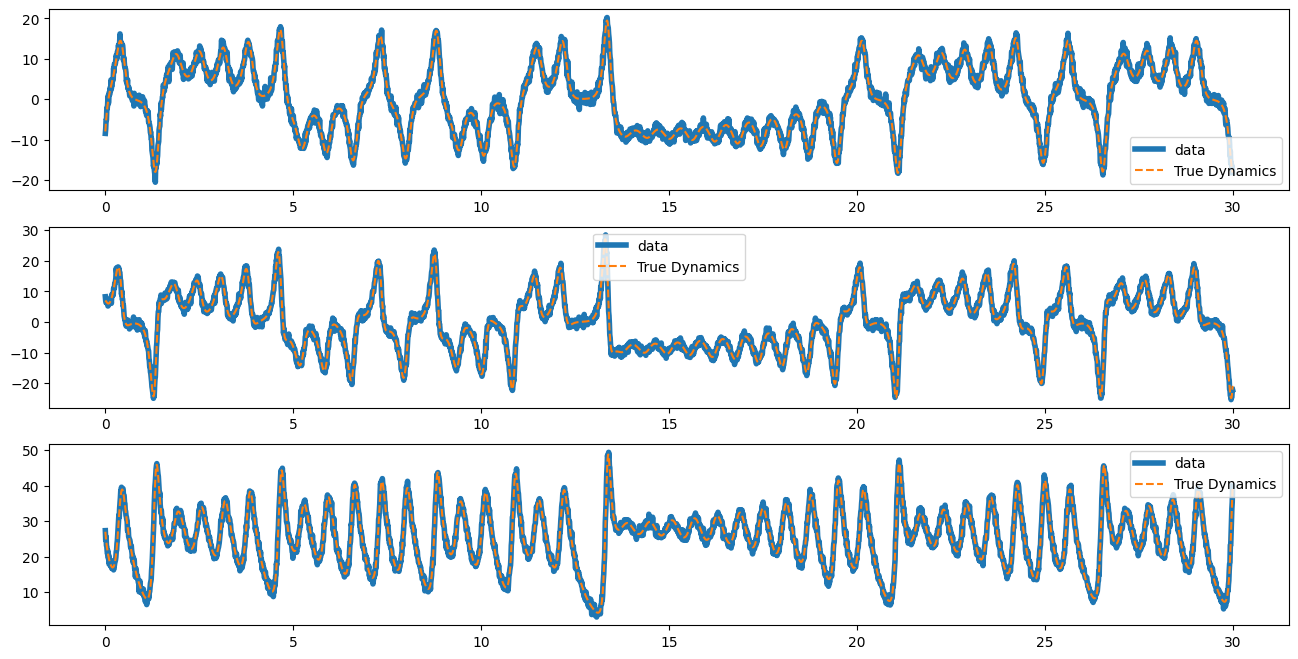

In [ ]:
t_span = np.array([0,30])
t_eval = np.arange(0,30,0.01)
noise_ratio = 0.1



sigma = 10
rho = 28
beta = 8/3

def rhs(t, s):
            # z = [x, y, eta, mx, cx, my, cy]
            x, y, z = s



            dx = sigma*(y-x)
            dy = x*(rho-z)
            dz = x*y-beta*z



            return np.array([dx, dy, dz])

x0 = np.array([-8 ,7 ,27]).T


sol = solve_ivp(fun=rhs, t_eval=t_eval, t_span=t_span, y0=x0, rtol=1e-6)
print(sol.success, sol.message, sol.t[-1], sol.y.T.shape)


x = sol.y.T
t = sol.t
xobs = addNoise(x=sol.y.T,noise_ratio=noise_ratio)

# plt.plot(sol.t,xobs)
fig = plt.figure(figsize=(16, 8))
c = 1
n = xobs.shape[1]
for d in range(n):
    plt.subplot(n, 1, c)
    plt.plot(t, xobs[:, d], label = "data", linewidth = 4)
    plt.plot(t, x[:, d], "--", label = 'True Dynamics',)
    c = c + 1
    plt.legend()

In [49]:
WSINDy_model = ws.wsindy(polys=np.arange(0, 3),ld=0.05
                         )

#Uniform
WSINDy_model.getWSindyUniform(xobs, t, L = 30, overlap=0.7)

t_ws, WSINDy_sim = WSINDy_model.simulate(t_span = [t[0],t[-1]], t_eval = t, x0 = xobs[0,:])

recoverDynamics(WSINDy_model)

True The solver successfully reached the end of the integration interval. 29.990000000000002 (3000, 3)
dx0/dt = 4.6996 + (-0.2185)x2 + (10.1355)x1 + (-10.1475)x0 + (-0.0479)x1^2 + (0.0476)x0x1 + (0.0233)x0^2
dx1/dt = 14.4934 + (-2.0232)x2 + (-0.1593)x1 + (28.0823)x0 + (0.0647)x2^2 + (-0.0893)x1^2 + (-0.9960)x0x2 + (0.3657)x0x1 + (-0.3806)x0^2
dx2/dt = -2.2479 + (-2.5268)x2 + (-0.0831)x1 + (1.0373)x0x1 + (-0.0575)x0^2


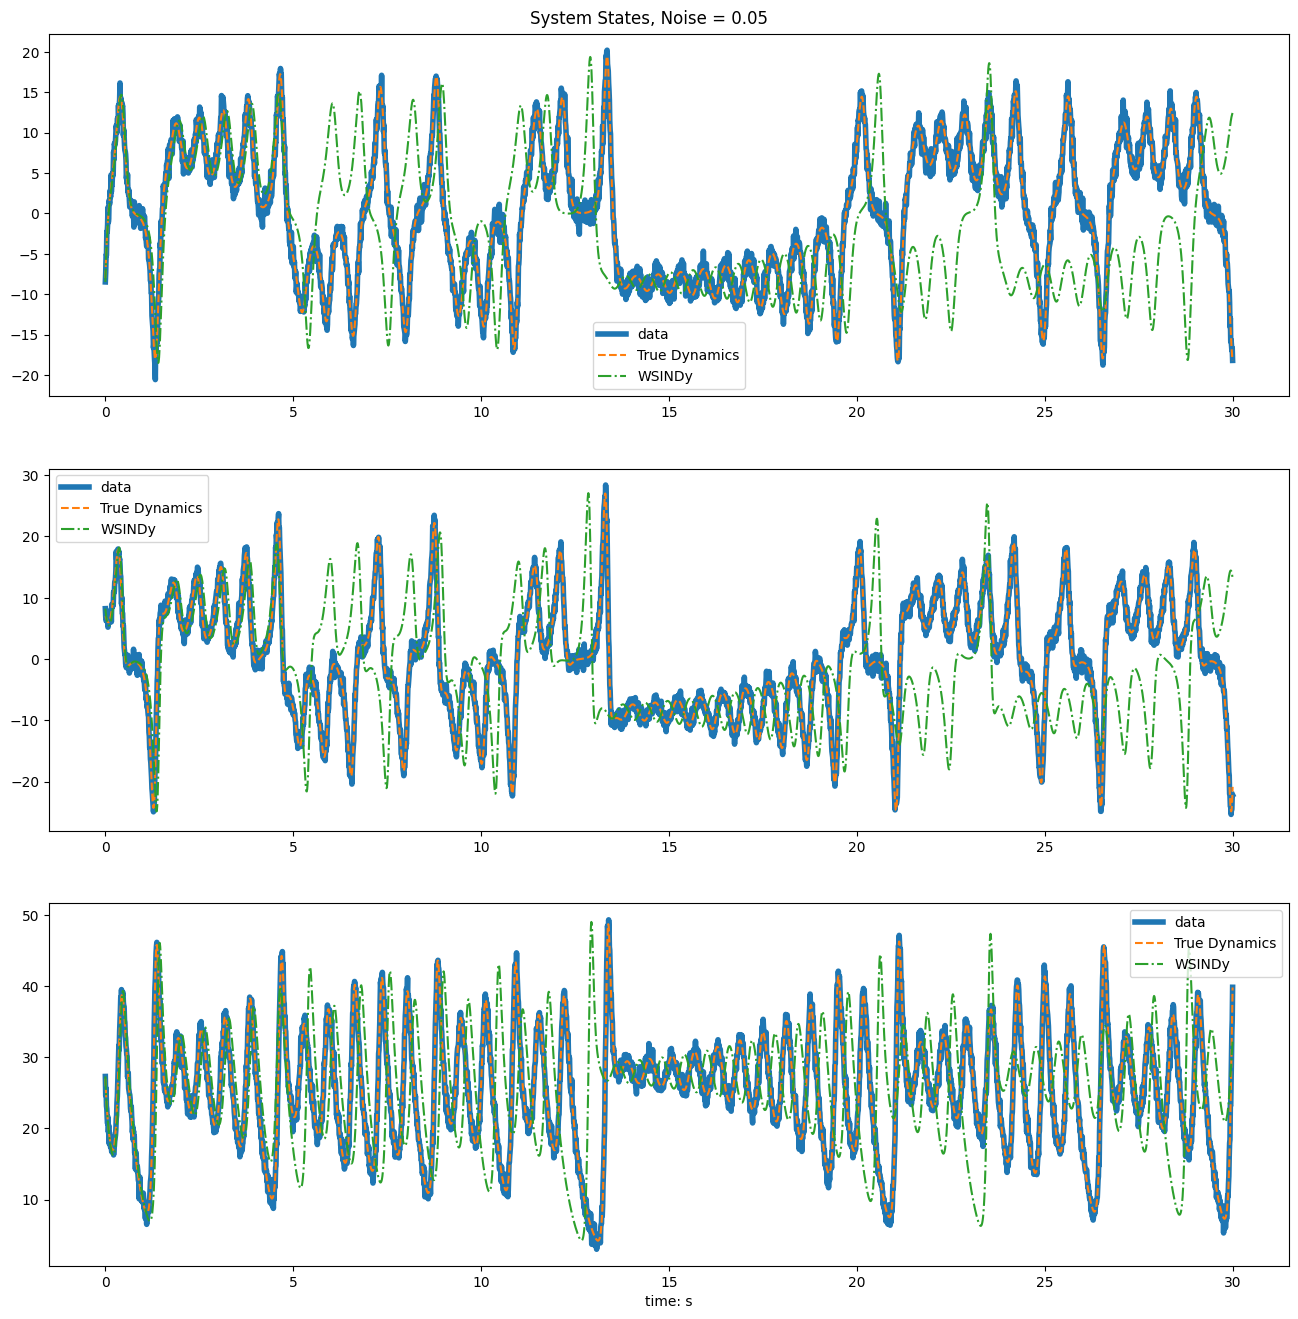

In [50]:
fig = plt.figure(figsize=(16, 16))
c = 1
n = xobs.shape[1]
plt.suptitle(f"System States, Noise = {noise_ratio}",y=0.895)

# plt.xlabel('time: s')
for d in range(n):
    plt.subplot(n, 1, c)
    plt.plot(t, xobs[:, d], label = "data", linewidth = 4)
    plt.plot(t, x[:, d], linestyle = "--", label = 'True Dynamics',) #marker = 'o', markevery=300)
    plt.plot(t_ws, WSINDy_sim[:, d], linestyle='dashdot', label = 'WSINDy') #marker = 'v', markevery = 200)
    # plt.subplots_adjust(hspace=0.4)
    if d == n - 1:
        plt.xlabel('time: s')
    
    c = c + 1
    plt.legend()
    

# plt.show()

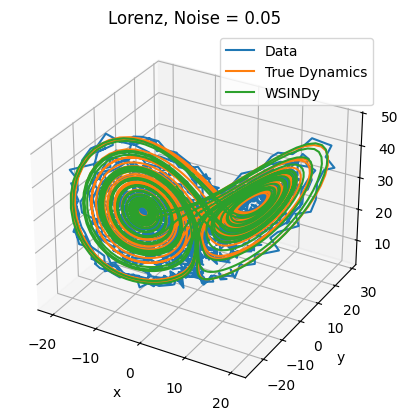

In [52]:
fig = plt.figure()
ax = plt.axes(projection = '3d')
ax.set_zlabel('z',labelpad=20)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.plot3D(xobs[:,0],xobs[:,1],xobs[:,2])
ax.plot3D(x[:,0],x[:,1],x[:,2])#,linestyle = 'dashdot')
ax.plot3D(WSINDy_sim[:,0],WSINDy_sim[:,1],WSINDy_sim[:,2])#,'--')
plt.legend(['Data','True Dynamics','WSINDy'])
plt.title(f"Lorenz, Noise = {noise_ratio}")


plt.show()